# Importing the dependencies

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the dataset and perform Preprocessing

In [9]:
dataset = pd.read_csv('Big mart sales.csv')
dataset.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


In [10]:
dataset.shape

(8523, 12)

In [11]:
dataset.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [13]:
dataset.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Categorical feature:


*  Item_Identifier
*  Item_Fat_Content
*  Item_Type
*  Outlet_Identifier
*  Outlet_Size
*  Outlet_Location_Type
*  Outlet_Type









In [14]:
# Filling the missing value of the 'Item_weight' with the mean of that column
dataset['Item_Weight'].fillna(dataset['Item_Weight'].mean(), inplace=True)

/tmp/ipython-input-3128194298.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Item_Weight'].fillna(dataset['Item_Weight'].mean(), inplace=True)


In [15]:
dataset.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [16]:
# find the mode of the 'outlet_size' column
mode_of_outlet_size = dataset.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))
print(mode_of_outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [17]:
missing_value = dataset['Outlet_Size'].isnull()
print(missing_value)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [50]:
for index, row in dataset.loc[missing_value, :].iterrows():
    dataset.loc[index, 'Outlet_Size'] = mode_of_outlet_size[row['Outlet_Type']].iloc[0]

KeyError: np.float64(0.0)

In [51]:
dataset.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


<Figure size 600x500 with 0 Axes>

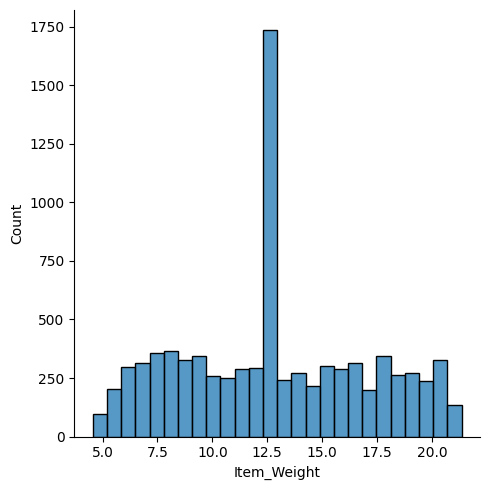

In [52]:
# item weight distribution
plt.figure(figsize=(6,5))
sns.displot(dataset['Item_Weight'])
plt.show()

<Figure size 600x500 with 0 Axes>

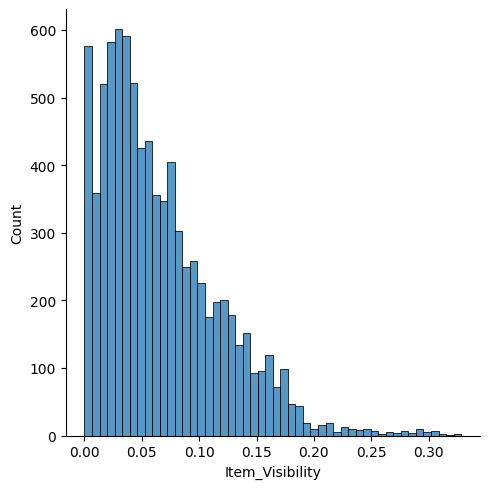

In [53]:
# item visibility distribution
plt.figure(figsize=(6,5))
sns.displot(dataset['Item_Visibility'])
plt.show()

<Figure size 600x500 with 0 Axes>

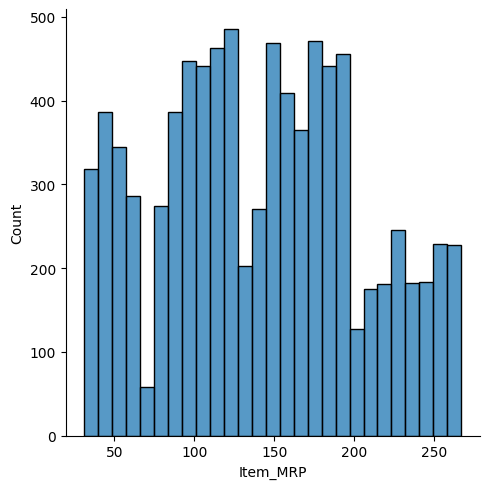

In [54]:
# item mrp distribution
plt.figure(figsize=(6,5))
sns.displot(dataset['Item_MRP'])
plt.show()

<Figure size 600x500 with 0 Axes>

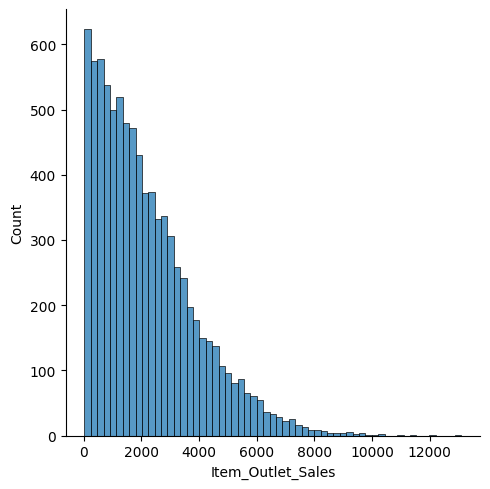

In [55]:
# item sales distribution
plt.figure(figsize=(6,5))
sns.displot(dataset['Item_Outlet_Sales'])
plt.show()

In [56]:
dataset['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
0,5517
1,3006


In [57]:
# Encoding the Fat content column
dataset.replace({'Item_Fat_Content': {'LF':"Low Fat", 'reg':"Regular",'low fat':"Low Fat"}}, inplace=True)

In [59]:
dataset['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
0,5517
1,3006


# Label Encoding

In [60]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [61]:
# Encoding the item identifier column
dataset['Item_Identifier'] = label.fit_transform(dataset['Item_Identifier'])

# encoding the item fat content column
dataset['Item_Fat_Content'] = label.fit_transform(dataset['Item_Fat_Content'])

# encoding the item type column
dataset['Item_Type'] = label.fit_transform(dataset['Item_Type'])

# encoding the outlet identifier column
dataset['Outlet_Identifier'] = label.fit_transform(dataset['Outlet_Identifier'])

# encoding the outlet size column
dataset['Outlet_Size'] = label.fit_transform(dataset['Outlet_Size'])

# encoding the outlet location type column
dataset['Outlet_Location_Type'] = label.fit_transform(dataset['Outlet_Location_Type'])

# encoding outlet type column
dataset['Outlet_Type'] = label.fit_transform(dataset['Outlet_Type'])

In [32]:
dataset.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700


# Spliting the dataset into input and output data

In [33]:
x = dataset.drop(columns='Item_Outlet_Sales', axis=1)
y = dataset['Item_Outlet_Sales']

# Spliting into training and testing data

In [34]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [35]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((6818, 11), (1705, 11), (6818,), (1705,))

# Model Training

In [62]:
from xgboost import XGBRegressor
xgb = XGBRegressor(objective='reg:squarederror', colsample_bytree=1.0, learning_rate=0.1, max_depth=3, subsample=1.0)

In [63]:
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

In [64]:
xgb.score(x_train, y_train)

0.6268615733056103

In [65]:
xgb.score(x_test, y_test)

0.6073173802755962

# HyperParameter Tunning

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}
